In [1]:
# DAY 28 - OPTIMIZED ML SYSTEM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (51290, 23)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Select features and create the target

feature_columns = [
    "sales",
    "quantity",
    "discount",
    "shipping_cost",
    "shipping_days"
]

X = df[feature_columns].astype(float)

# Target:
# 1 = Positive profit
# 0 = Zero or negative profit
y = (df["profit"] > 0).astype(int)

print("Features selected successfully!")

print("\nFeatures used:")
print(feature_columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


Features selected successfully!

Features used:
['sales', 'quantity', 'discount', 'shipping_cost', 'shipping_days']

X shape: (51290, 5)
y shape: (51290,)

Target distribution:
profit
1    38079
0    13211
Name: count, dtype: int64


In [4]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split completed!")

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Data split completed!
Training data: (41032, 5)
Testing data: (10258, 5)


In [5]:
# Build the Machine Learning pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

print("ML pipeline created successfully!")
print(pipeline)

ML pipeline created successfully!
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])


In [6]:
# Train the pipeline

pipeline.fit(X_train, y_train)

# Make predictions on the test data
y_pred = pipeline.predict(X_test)

# Calculate test accuracy
pipeline_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Pipeline trained successfully!")
print("Test Accuracy:", round(pipeline_accuracy, 3))

Pipeline trained successfully!
Test Accuracy: 0.913


In [7]:
# Evaluate the pipeline using 5-Fold Cross-Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation completed!")

print("\nFold Accuracy Scores:")
print(cv_scores.round(3))

print("\nMean CV Accuracy:", round(cv_scores.mean(), 3))
print("CV Standard Deviation:", round(cv_scores.std(), 3))

Cross-validation completed!

Fold Accuracy Scores:
[0.914 0.912 0.915 0.912 0.91 ]

Mean CV Accuracy: 0.913
CV Standard Deviation: 0.002


In [8]:
# Hyperparameter tuning for the Random Forest inside the pipeline

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 3))

Hyperparameter tuning completed!

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best Cross-Validation Accuracy:
0.92


In [9]:
# Evaluate the optimized pipeline on the test data

best_pipeline = grid_search.best_estimator_

optimized_predictions = best_pipeline.predict(X_test)

optimized_accuracy = accuracy_score(
    y_test,
    optimized_predictions
)

print("Optimized pipeline evaluation completed!")

print("Optimized Test Accuracy:", round(optimized_accuracy, 3))

Optimized pipeline evaluation completed!
Optimized Test Accuracy: 0.92


In [10]:
# Compare original and optimized pipeline performance

performance_comparison = pd.DataFrame({
    "Model": [
        "Original Pipeline",
        "Optimized Pipeline"
    ],
    "Test Accuracy": [
        pipeline_accuracy,
        optimized_accuracy
    ]
})

performance_comparison["Test Accuracy"] = (
    performance_comparison["Test Accuracy"].round(3)
)

print("Performance comparison:")
print(performance_comparison)


Performance comparison:
                Model  Test Accuracy
0   Original Pipeline          0.913
1  Optimized Pipeline          0.920


In [11]:
# Calculate the change in performance

original_accuracy = performance_comparison.loc[
    performance_comparison["Model"] == "Original Pipeline",
    "Test Accuracy"
].iloc[0]

optimized_accuracy_value = performance_comparison.loc[
    performance_comparison["Model"] == "Optimized Pipeline",
    "Test Accuracy"
].iloc[0]

accuracy_change = (
    optimized_accuracy_value - original_accuracy
)

print("Original Pipeline Accuracy:", original_accuracy)
print("Optimized Pipeline Accuracy:", optimized_accuracy_value)
print("Accuracy Change:", round(accuracy_change, 3))

Original Pipeline Accuracy: 0.913
Optimized Pipeline Accuracy: 0.92
Accuracy Change: 0.007


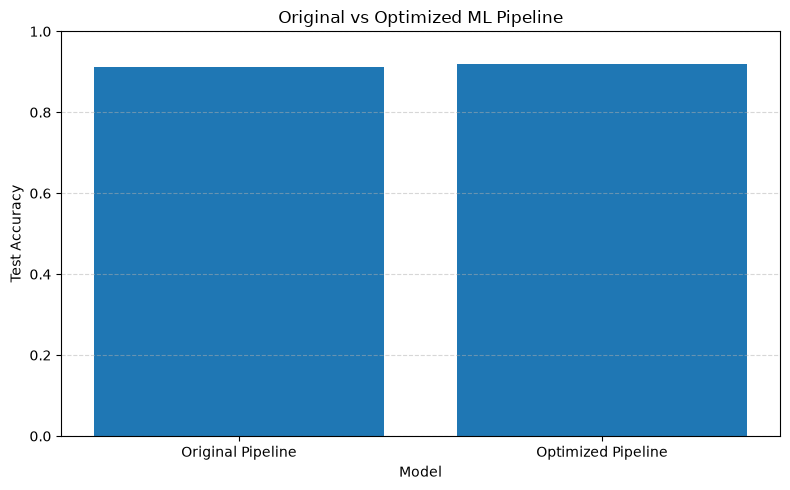

In [12]:
# Visualize original vs optimized pipeline performance

plt.figure(figsize=(8, 5))

plt.bar(
    performance_comparison["Model"],
    performance_comparison["Test Accuracy"]
)

plt.title("Original vs Optimized ML Pipeline")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

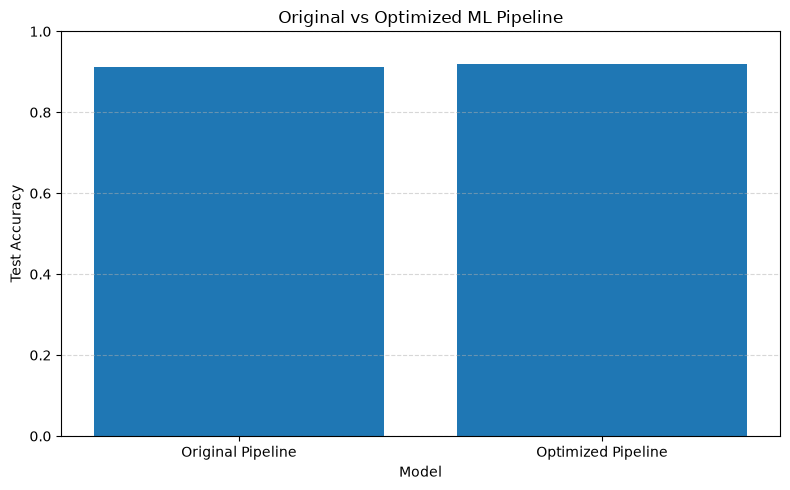

Performance graph saved successfully!
File: pipeline_performance_comparison.png


In [13]:
# Save the performance comparison graph

plt.figure(figsize=(8, 5))

plt.bar(
    performance_comparison["Model"],
    performance_comparison["Test Accuracy"]
)

plt.title("Original vs Optimized ML Pipeline")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "pipeline_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Performance graph saved successfully!")
print("File: pipeline_performance_comparison.png")

In [14]:
# Save the final performance report

final_performance_report = performance_comparison.copy()

final_performance_report["Accuracy Change"] = [
    0,
    accuracy_change
]

final_performance_report.to_csv(
    "final_performance_report.csv",
    index=False
)

print("Final performance report saved successfully!")
print("File: final_performance_report.csv")

print("\nFinal Performance Report:")
print(final_performance_report)

Final performance report saved successfully!
File: final_performance_report.csv

Final Performance Report:
                Model  Test Accuracy  Accuracy Change
0   Original Pipeline          0.913            0.000
1  Optimized Pipeline          0.920            0.007


In [15]:
# Day 28 optimization summary

print("==============================================")
print(" DAY 28 - ML OPTIMIZATION SUMMARY")
print("==============================================")

print("\n1. Preprocessing:")
print("StandardScaler was included in the ML pipeline.")

print("\n2. Model:")
print("Random Forest Classifier was used.")

print("\n3. Validation:")
print("5-Fold Stratified Cross-Validation was used.")

print("\n4. Hyperparameter Tuning:")
print("GridSearchCV was used to search for better Random Forest settings.")

print("\n5. Performance:")
print("Original Pipeline Accuracy:", original_accuracy)
print("Optimized Pipeline Accuracy:", optimized_accuracy_value)
print("Accuracy Change:", round(accuracy_change, 3))

print("\n6. Engineering Tradeoff:")
print("Hyperparameter tuning can improve model performance,")
print("but it requires additional computation and training time.")

print("\n7. Key Learning:")
print("Combining preprocessing, validation, and tuning")
print("creates a more reproducible ML workflow.")

print("\n==============================================")
print(" Day 28 optimization analysis completed!")
print("==============================================")

 DAY 28 - ML OPTIMIZATION SUMMARY

1. Preprocessing:
StandardScaler was included in the ML pipeline.

2. Model:
Random Forest Classifier was used.

3. Validation:
5-Fold Stratified Cross-Validation was used.

4. Hyperparameter Tuning:
GridSearchCV was used to search for better Random Forest settings.

5. Performance:
Original Pipeline Accuracy: 0.913
Optimized Pipeline Accuracy: 0.92
Accuracy Change: 0.007

6. Engineering Tradeoff:
Hyperparameter tuning can improve model performance,
but it requires additional computation and training time.

7. Key Learning:
Combining preprocessing, validation, and tuning
creates a more reproducible ML workflow.

 Day 28 optimization analysis completed!


In [16]:
# Final Day 28 file check

import os

files = [
    "day28.ipynb",
    "final_performance_report.csv",
    "pipeline_performance_comparison.png",
    "week4_reflection.md",
    "README.md"
]

print("==============================================")
print(" DAY 28 - FILE CHECK")
print("==============================================")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

print("==============================================")
print(" Day 28 file check completed!")
print("==============================================")

 DAY 28 - FILE CHECK
✅ day28.ipynb
✅ final_performance_report.csv
✅ pipeline_performance_comparison.png
✅ week4_reflection.md
✅ README.md
 Day 28 file check completed!
